# Get tcBF and acBF STEM image with GPU

**Before running the notebook, making sure to install the source code following the instruction in GitHub repo: https://github.com/chiahao3/fast-acbf**

> Note: This notebook is designed to demonstrate how to get tilt-corrected and aberration-corrected Bright-field STEM (tcBF and acBF) images from 4D-STEM data

Author: 
- Dr. Chia-Hao Lee , chia-hao.lee@cornell.edu

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
work_dir = "./" # Change the working directory if needed, but by default it's at the root level of this repo
os.chdir(work_dir)
print("Current working dir: ", os.getcwd())

Current working dir:  /home/cl2696/altas/workspace/fast-acbf


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from ptyrad.optics.constants import get_wavelength_ang
from ptyrad.io.generic import load_raw
from ptyrad.io.handlers import load_array_from_file
from ptyrad.runtime.diagnostics import print_system_info

In [4]:
print_system_info()

### System information ###
Platform: Linux-6.8.0-101-generic-x86_64-with-glibc2.35
Operating System: Linux 6.8.0-101-generic
OS Version: #101~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Feb 11 13:19:54 UTC 
Machine: x86_64
Processor: x86_64
Available CPU cores: 32
Total Memory: 62.05 GB
Available Memory: 52.29 GB
 
### GPU information ###
CUDA Available: True
CUDA Version: 12.6
Available CUDA GPUs: ['NVIDIA RTX 5000 Ada Generation', 'NVIDIA RTX 5000 Ada Generation']
CUDA Compute Capability: ['8.9', '8.9']
  INFO: For torch.compile with Triton, you'll need CUDA GPU with Compute Capability >= 7.0.
        In addition, Triton does not directly support Windows.
        For Windows users, please follow the instruction and download `triton-windows` from https://github.com/woct0rdho/triton-windows.
MIG (Multi-Instance GPU) mode = False
  INFO: MIG splits a physical GPU into multiple GPU slices, but multiGPU does not support these MIG slices.
        In addition, multiGPU is currently only availabl

# Initialize dataset

Note that the scan rotation was NOT implemented yet

Relative flipping / transpose are handled during data loading

In [5]:
# tBL-WSe2
file_path = 'data/Figure 4/scan_x128_y128.raw'

dataset = load_raw(file_path, shape=(16384,128,128)) # Loading this takes ~ 0.5 sec from local disk to RAM
dataset = np.flip(dataset, axis=1) # Flip (1,0,0)
dataset = dataset.reshape(128,128,128,128)
mean_DP = dataset.mean((0,1))
dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

kv = 80
max_alpha = 25 # mrad
defocus = -80 # Ang, positive is underfocs. Note that we can let AD refine this value later.
scan_step_size = 0.43 # Ang
Npix = 128
dk = 0.0400 # Ang-1

##====================================================

# # MOSS6
# file_path = 'data/MOSS6/ExperimentalData_MOSS-6_Fig.3/scan_x256_y256.raw'

# dataset = load_raw(file_path, shape=(65536,128,128))
# dataset = np.flip(dataset, axis=1) # Flip (1,0,0)
# dataset = dataset.reshape(256,256,128,128)
# dataset[dataset < 20] = 0 # Clip below 20
# mean_DP = dataset.mean((0,1))
# dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

# kv = 300
# max_alpha = 10 # mrad
# defocus = 885 # Ang, positive is underfocs
# scan_step_size = 1.051 # Ang
# Npix = 128
# dk = 0.0264 # Ang-1

##====================================================

# # PSO
# file_path = 'data/PSO/60_PSO_area9_41Mx_scan1_CL770mm_CA50um_21p4mrad_spot9_mono21p51_30pA_df20nm_50x_50y_100z_432step_x128_y128.raw'

# dataset = load_raw(file_path, shape=(16384,128,128)) # Loading this takes ~ 0.5 sec from local disk to RAM
# dataset = np.transpose(dataset, (0,2,1)) #
# dataset = dataset.reshape(128,128,128,128)
# mean_DP = dataset.mean((0,1))
# dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

# kv = 300
# max_alpha = 21.4 # mrad
# defocus = -200 # Ang, positive is underfocs
# scan_step_size = 0.41 # Ang
# Npix = 128
# dk = 0.0417 # Ang-1

##====================================================

# tBL-STO
# file_path = 'data/20240820_STO_bilayer_04_Hari/data_roi1_Ndp256_dp.hdf5'

# dataset = load_array_from_file(file_path, key='dp') # Loading this takes ~ 0.5 sec from local disk to RAM
# dataset = dataset.reshape(256,256,128,128)
# mean_DP = dataset.mean((0,1))
# dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

# kv = 300
# max_alpha = 30 # mrad
# defocus = -120 # Ang, positive is underfocs
# scan_step_size = 0.38595 # Ang
# Npix = 128
# dk = 0.0550 # Ang-1

In [6]:
dataset.shape

(128, 128, 128, 128)

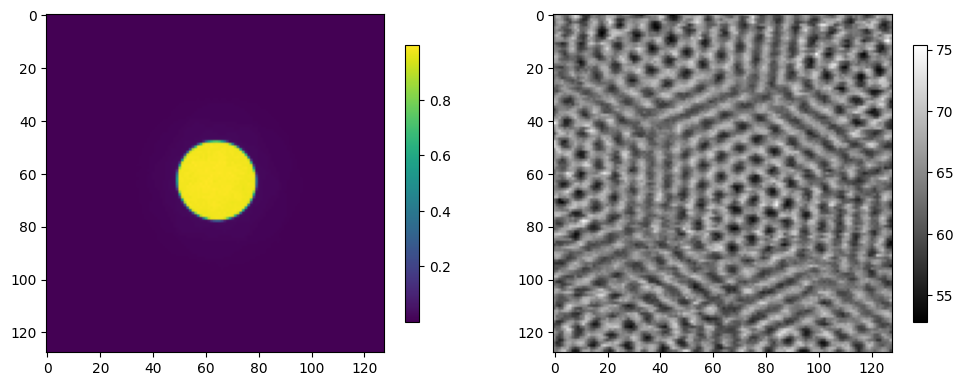

In [7]:
fig, axs = plt.subplots(1,2, figsize=(12,6))
im0 = axs[0].imshow(dataset.mean(axis=(0,1)))
im1 = axs[1].imshow(dataset[:,:,60:68,60:68].sum(axis=(-2,-1)), cmap='gray')
fig.colorbar(im0, shrink=0.6)
fig.colorbar(im1, shrink=0.6)
plt.show()

# Initialize BFSolver

`BFSolver` holds the 4D-dataset, and produces either tcBF or acBF, with flexible aberration refinement methods that can be chained together.

In [8]:
from fast_acbf import BFSolver

Extracted 681 vBF images within the max alpha angle = 24.7 mrad.


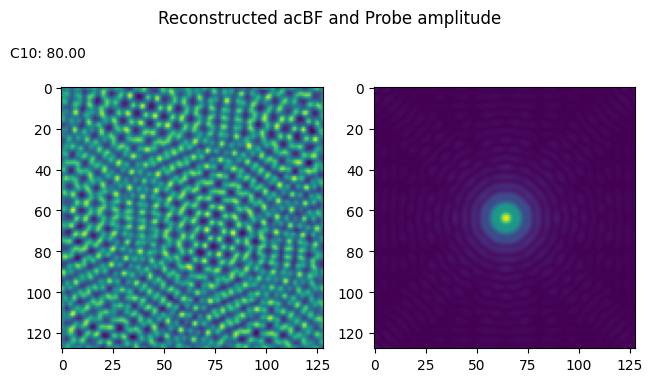

In [9]:
# Initialize the BFSolver takes ~ 0.3 sec, including sending vBF data to GPU
bf = BFSolver(dataset, 
              max_alpha=max_alpha-0.3, 
              scan_step_size=scan_step_size, 
              dk=dk, 
              wavelength=get_wavelength_ang(kv=kv), 
              max_order=3,
              aberrations={
                'C10': -defocus, #C10 is -df, positive C10 is overfocus 
                'C12': 0,
                'phi12': 0, 
                'C21': 0,
                'C23': 0,
                }, 
              device='cuda',
            )

# Plot the initial reconstruction without any refinement
# Calculation ~ 0.01 sec, but plotting takes ~ 0.3 - 0.6 sec
bf.plot_reconstruction(mode='acBF', upscale=1)

## Aberration Refinement

For optimal reconstruction quality, we can refine the initial aberrations.

`BFSolver` currently implements 2 refinement methods (API might change in the future):

- `.refine_defocus()`: Run a line search for defocus, very fast, good for quick initialization
- `.refine_aberrations()`: Run an AD optimization loop to refine aberrations to reach highest image quality

It's recommended to do a 2-stage approach as follows if you aren't sure about your initial defocus.

Starting defocus line search: 50 points between 0 and 300 Ang
Optimal C10 found at 116.33 Ang (max)


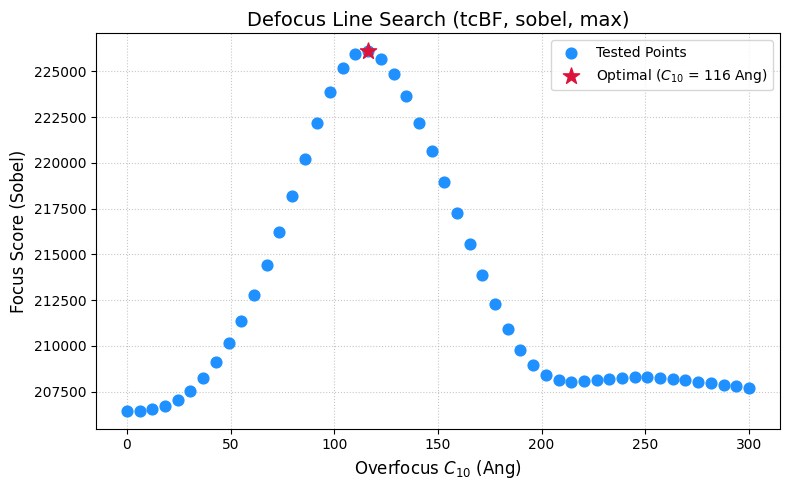

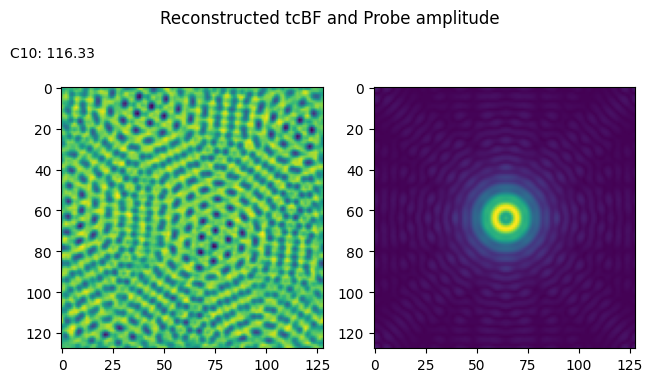

In [10]:
# Apply the defocus line search and plot the refined reconstruction
# Line searching 50 points of 681 images takes ~ 0.5 sec, plotting takes additional 0.3 sec
# Taking 5-10 points might be good enough for rough start
bf.refine_defocus(search_range=[0, 300], 
                num_points=50, 
                metric='sobel', 
                method='max', 
                plot_line_search=True,
                mode='tcBF'
                )
bf.plot_reconstruction()

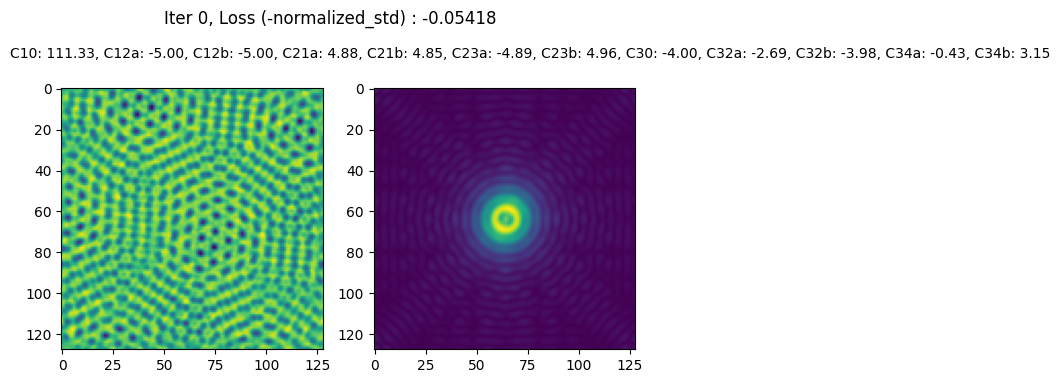

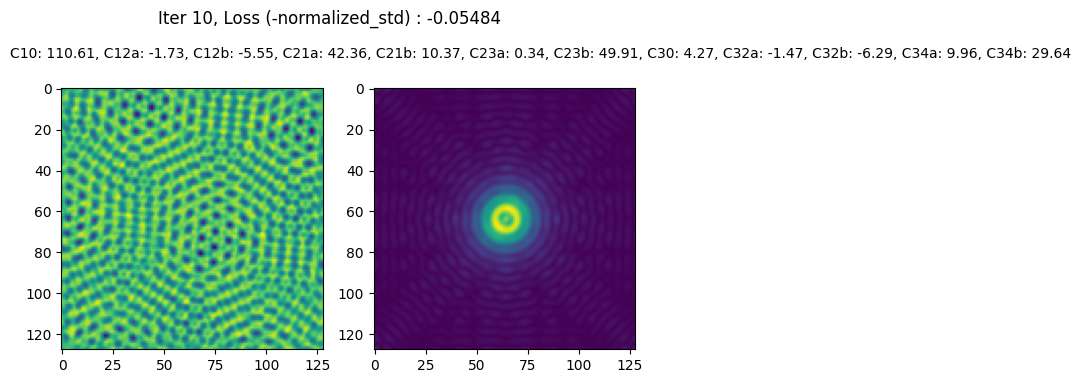

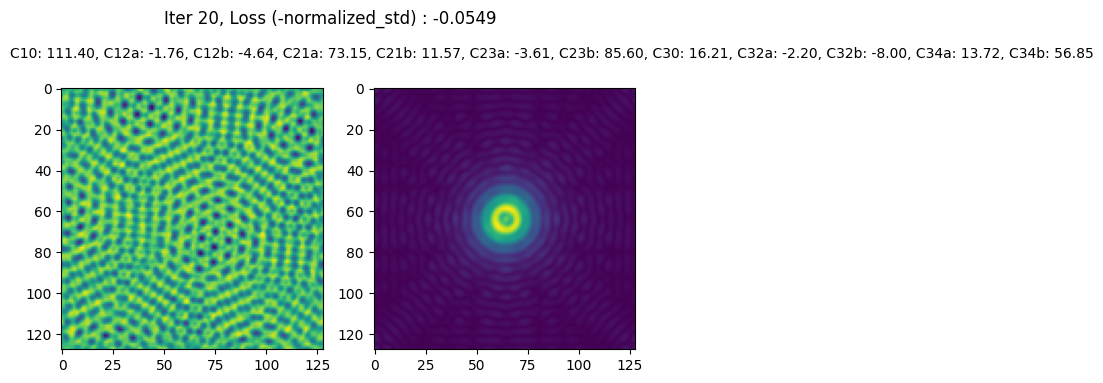

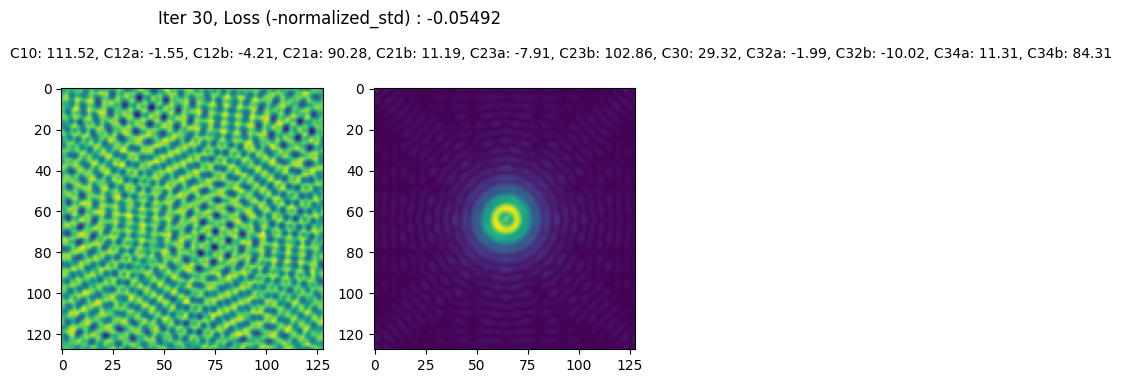

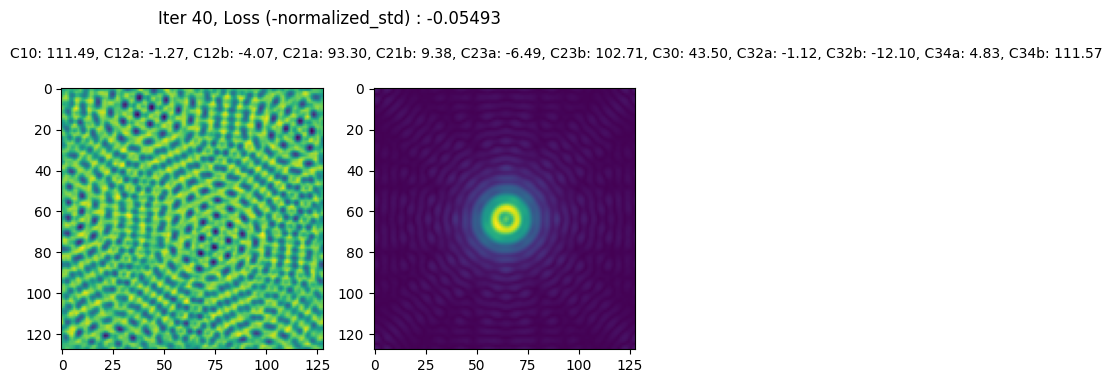

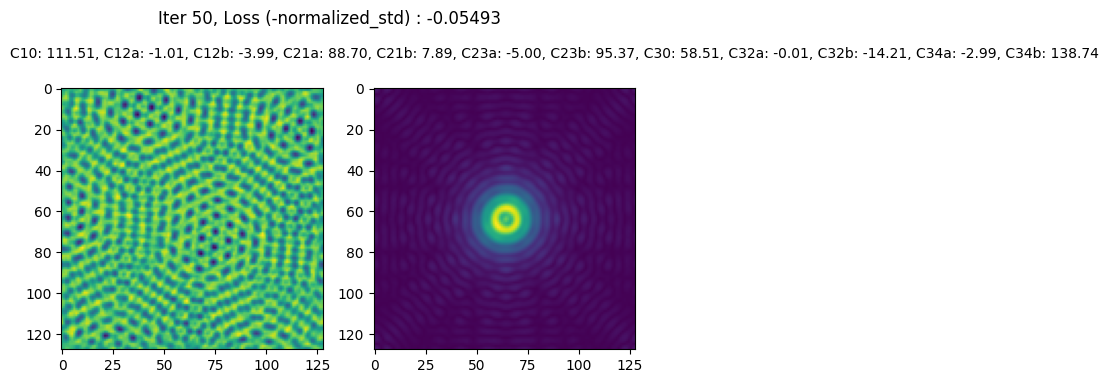

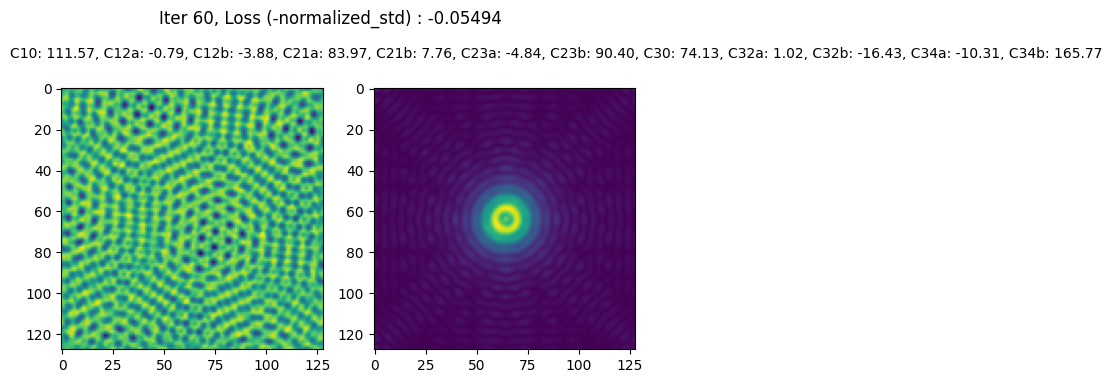

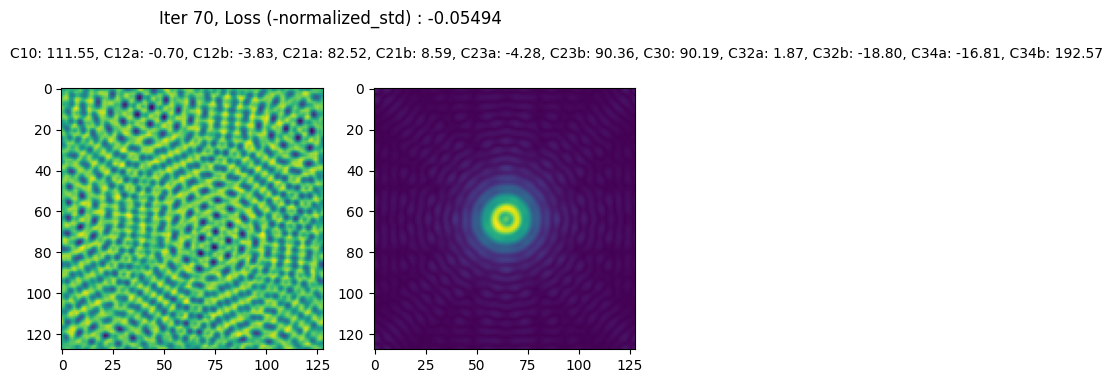

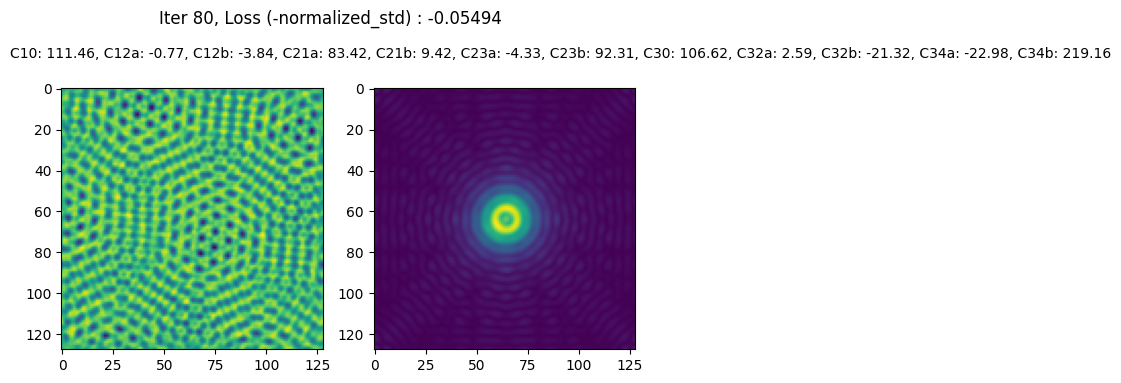

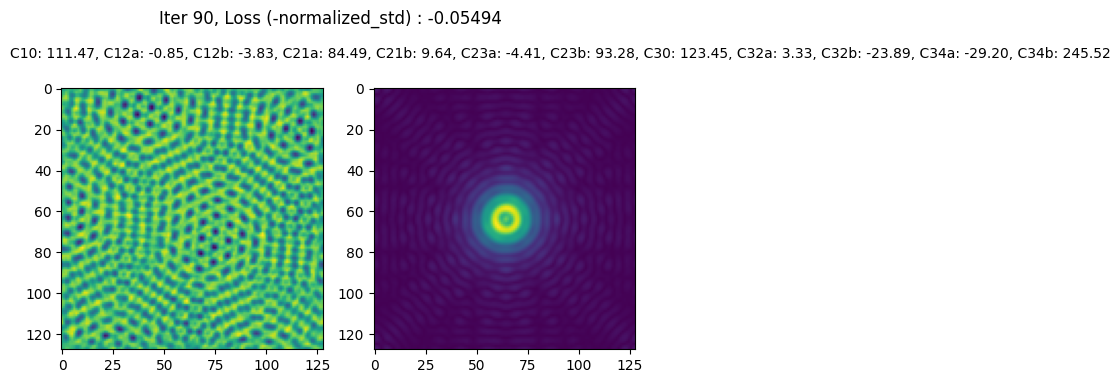

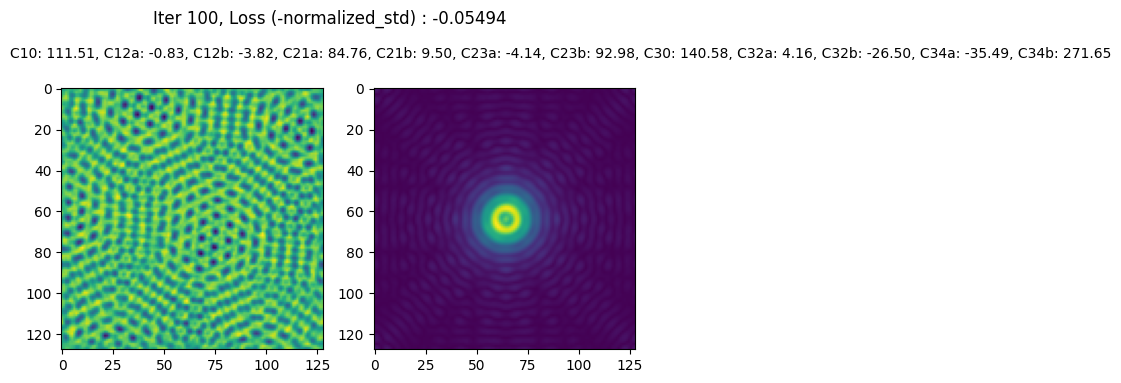

Krivanek Haider     Magnitude   Angle (°)  Description
-------------------------------------------------------------------------------
C1,0     C1         111.5060    -          Defocus (C10 = -df)
C1,2     A1         3.9063      -51.17     2-fold astigmatism
C2,1     3*B2       85.2914     6.39       Axial coma
C2,3     A2         93.0713     30.85      3-fold astigmatism
C3,0     C3         140.5760    -          Spherical aberration
C3,2     4*S3       26.8249     -40.54     Axial star aberration
C3,4     A3         273.9594    24.36      4-fold astigmatism


In [11]:
# Furthe apply the AD-based aberration optimization and plot the refined reconstruction
# 1000 iterations takes 20 sec, with reasonable initial guess (and defocus line search) we may only need 50 iterations (~ 1 sec)

# You might want to manually play with learning rate (lr) and iterations (iter) for best result
# Also, refine_aberrations() is most stable in 'tcBF' mode, because acBF might introduces wild amplitude variations
# You can disable plotting for fastest throughput
bf.refine_aberrations(iters=101, lr=5, metric='normalized_std', plot_recon_every_n_iter=10, save_dir=None, mode='tcBF')

bf.print_aberrations()

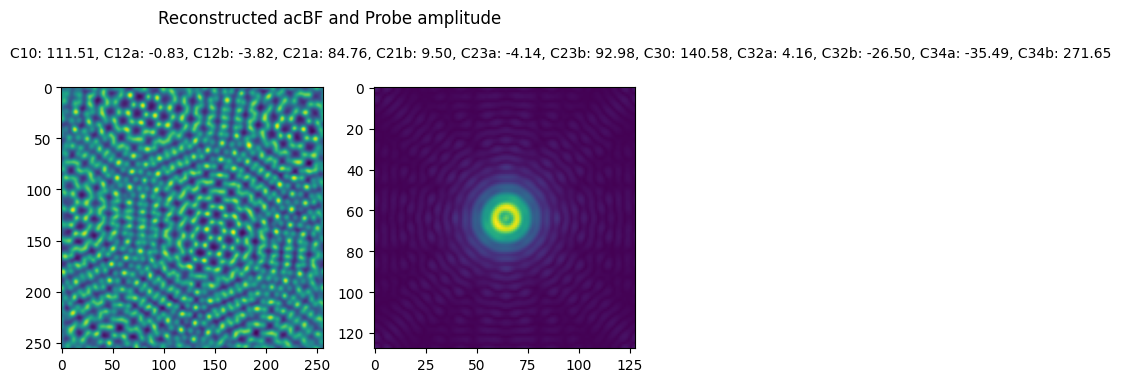

In [12]:
bf.plot_reconstruction(mode='acBF', upscale=2)

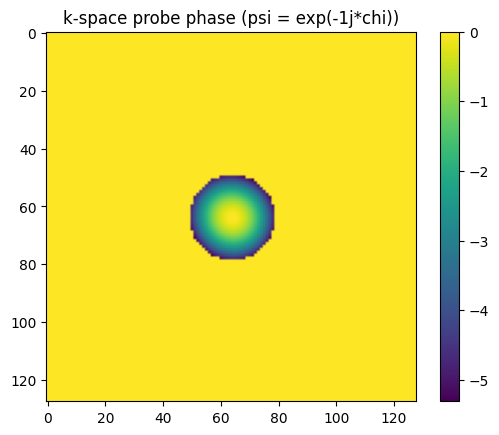

In [13]:
bf.plot_chi_surface(plot_probe_phase=True)

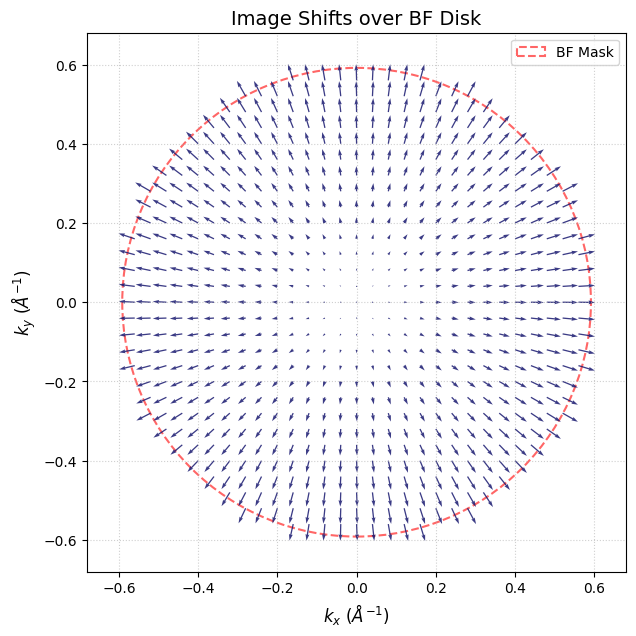

In [14]:
bf.plot_shift_quiver();

## Timing code for dev purpose

In [15]:
# Time the reconstruction time (i.e., shifting and summing all vBF images with optional CTF correction)
from ptyrad.solver.reconstruction import time_sync

repetition = 1000
total_t = 0
mode='tcBF'

for i in range(repetition):

    t0 = time_sync()
    bf.reconstruct(mode=mode, chunk_size=681, upscale=1)
    t1 = time_sync()
    
    total_t += (t1-t0)
print(f"Reconstructing {bf.bf_mask.sum()} vBF images in {mode} mode takes {total_t / repetition:.4f} sec")

Reconstructing 681.0 vBF images in tcBF mode takes 0.0023 sec
